# Purpose

- Check some very basic properties of covariance and correlation


In [1]:
library(tidyverse)
library(ggplot2)
library(patchwork)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ purrr::%||%()   masks base::%||%()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


# Linear relationship


## Covariance


### Correlated variables


[1] 100

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    1.0     4.0     5.0     5.1     7.0    11.0 

[1] 100

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 -4.383   5.782   9.758  10.112  14.296  29.328 

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


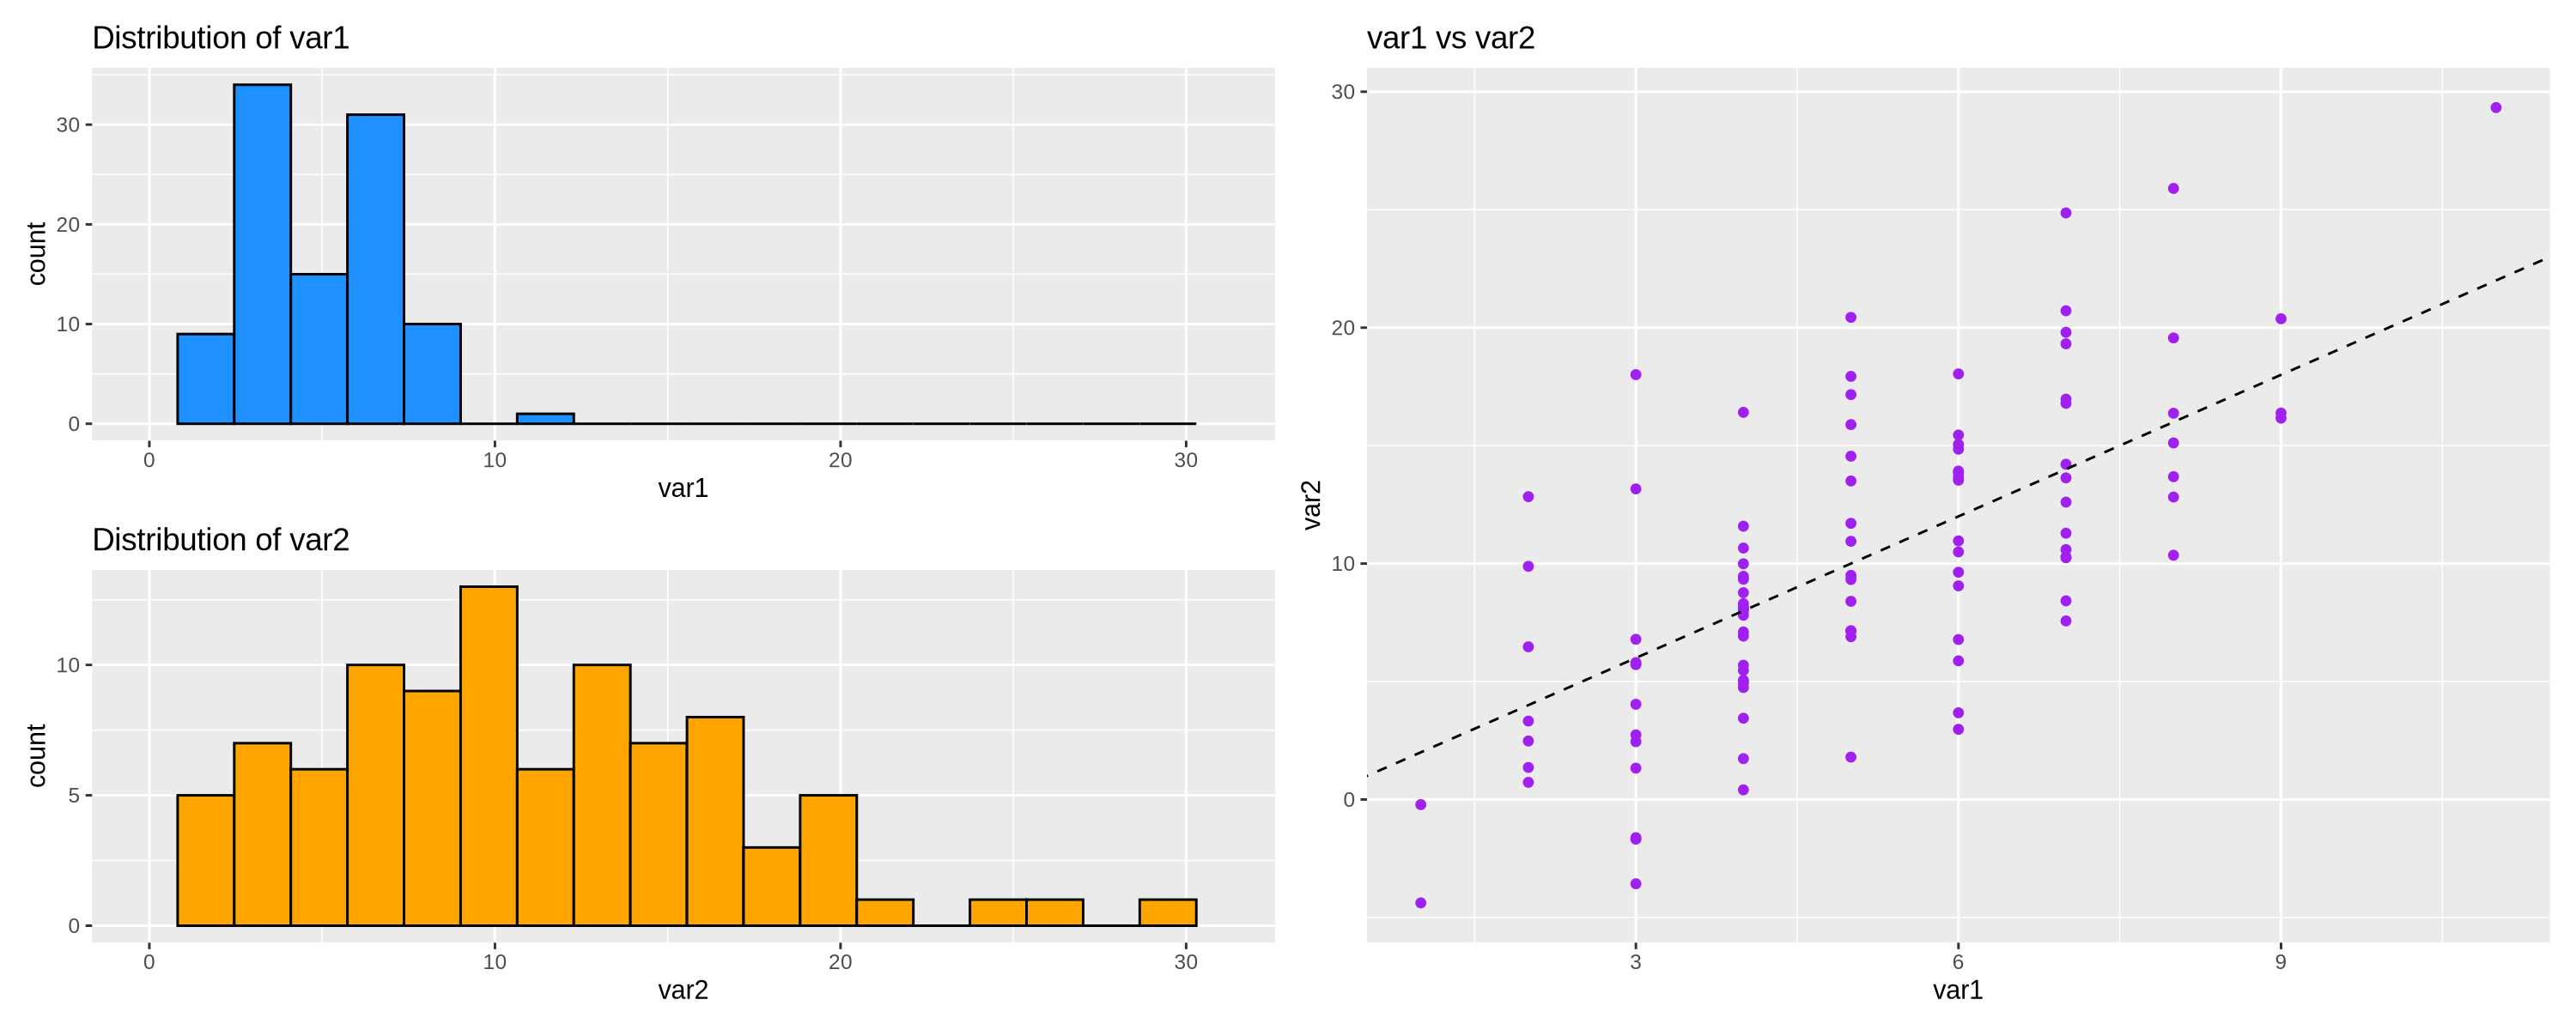

In [2]:
options(repr.plot.width = 15, repr.plot.height = 6, repr.plot.res = 200)

set.seed(1)

n_samples <- 100
var1 <- rpois(n_samples, 5)
var2 <- (var1 * 2) + rnorm(n_samples, 0, 5)

length(var1)
summary(var1)
length(var2)
summary(var2)

df <- data.frame(var1, var2)

# Create histograms for var1 and var2 with the same x-axis limits
x_limits <- range(c(var1, var2))
extension_fraction <- 0.05
new_max <- x_limits[2] + (x_limits[2] - x_limits[1]) * extension_fraction
x_limits <- c(-0.1, new_max)

hist_var1 <- ggplot(df, aes(x = var1)) +
    geom_histogram(bins = 20, fill = "dodgerblue", color = "black") +
    xlim(x_limits) +
    ggtitle("Distribution of var1")

hist_var2 <- ggplot(df, aes(x = var2)) +
    geom_histogram(bins = 20, fill = "orange", color = "black") +
    xlim(x_limits) +
    ggtitle("Distribution of var2")

# Create a scatterplot of var1 vs var2
scatter_plot <- ggplot(df, aes(x = var1, y = var2)) +
    geom_point(color = "purple") +
    geom_abline(slope = 2, intercept = 0, color = "black", linetype = "dashed") +
    ggtitle("var1 vs var2")

# Combine the plots into two columns
(hist_var1 / hist_var2) | scatter_plot +
    plot_layout(axis_titles = "collect")


In [25]:
covariance <- cov(var1, var2)
covariance


[1] 8.880096

In [26]:
# By hand

X <- mean(var1)
Y <- mean(var2)
head(X - var1)
head(Y - var2)

"-----Covariance------"
sum((X - var1) * (Y - var2)) / (n_samples - 1) # note the "- 1"


[1]  1.1  1.1  0.1 -2.9  2.1 -2.9

[1]   0.1215731   5.1722345  -1.5934959  -0.2410820  -3.0530160 -15.7898970

[1] "-----Covariance------"

[1] 8.880096

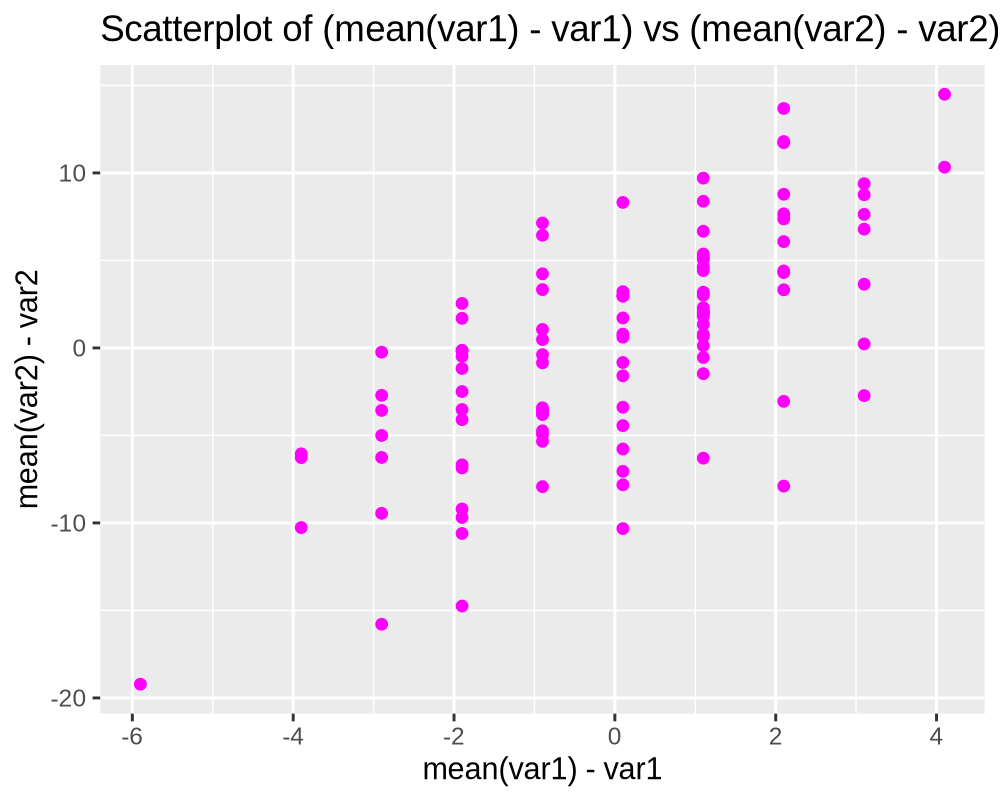

In [27]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 200)

# Create a data frame for the differences
df_diff <- data.frame(diff_var1 = X - var1, diff_var2 = Y - var2)

scatter_diff_plot <- ggplot(df_diff, aes(x = diff_var1, y = diff_var2)) +
    geom_point(color = "magenta") +
    ggtitle("Scatterplot of (mean(var1) - var1) vs (mean(var2) - var2)") +
    xlab("mean(var1) - var1") +
    ylab("mean(var2) - var2")

scatter_diff_plot


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


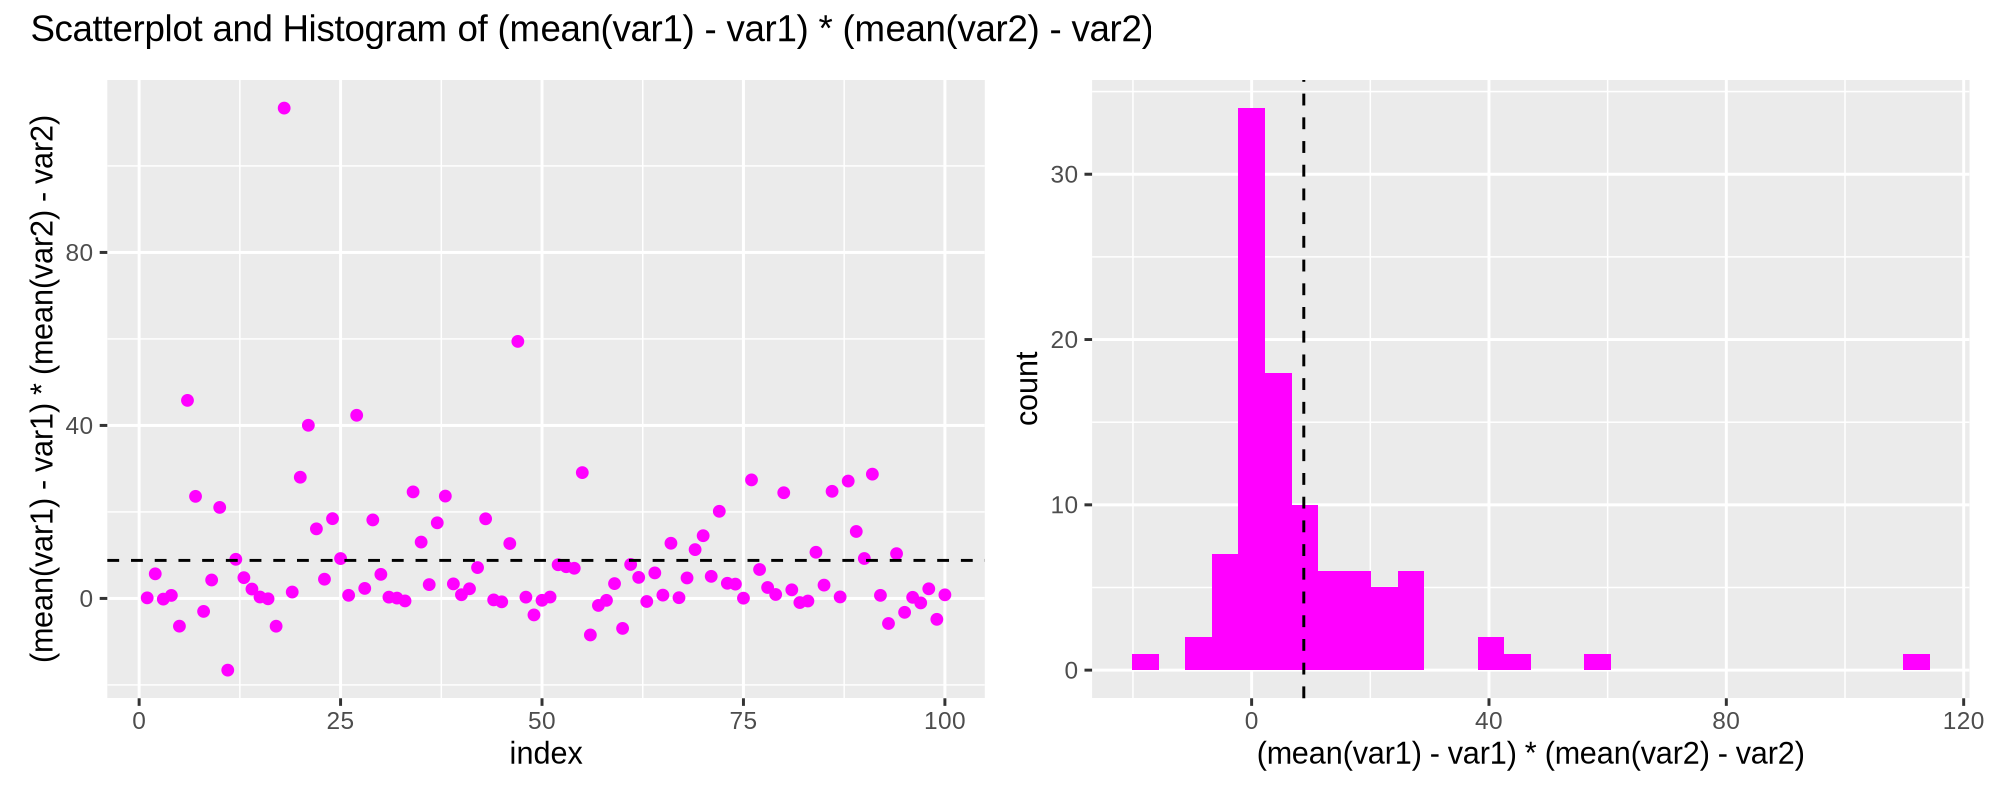

In [28]:
options(repr.plot.width = 10, repr.plot.height = 4, repr.plot.res = 200)

# Create a data frame for the differences
df_diff <- data.frame(covariance = (X - var1) * (Y - var2), x = 1:n_samples)
# Calculate the mean of the (almost) covariance
mean_covariance <- mean(df_diff$covariance)

scatter_plot <- ggplot(df_diff, aes(x = x, y = covariance)) +
    geom_point(color = "magenta") +
    geom_hline(yintercept = mean_covariance, color = "black", linetype = "dashed") +
    xlab("index") +
    ylab("(mean(var1) - var1) * (mean(var2) - var2)")
hist_plot <- ggplot(df_diff, aes(x = covariance)) +
    geom_histogram(fill = "magenta") +
    geom_vline(xintercept = mean_covariance, color = "black", linetype = "dashed") +
    xlab("(mean(var1) - var1) * (mean(var2) - var2)")

scatter_plot + hist_plot +
    plot_annotation(title = "Scatterplot and Histogram of (mean(var1) - var1) * (mean(var2) - var2)")


- If there's no covariance between variables, the difference between each variable's point to its mean should be distributed around 0, with expected value 0


### Uncorrelated variables


[1] 100

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    1.0     4.0     5.0     5.1     7.0    11.0 

[1] 100

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00    4.00    5.00    5.11    6.00   11.00 

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


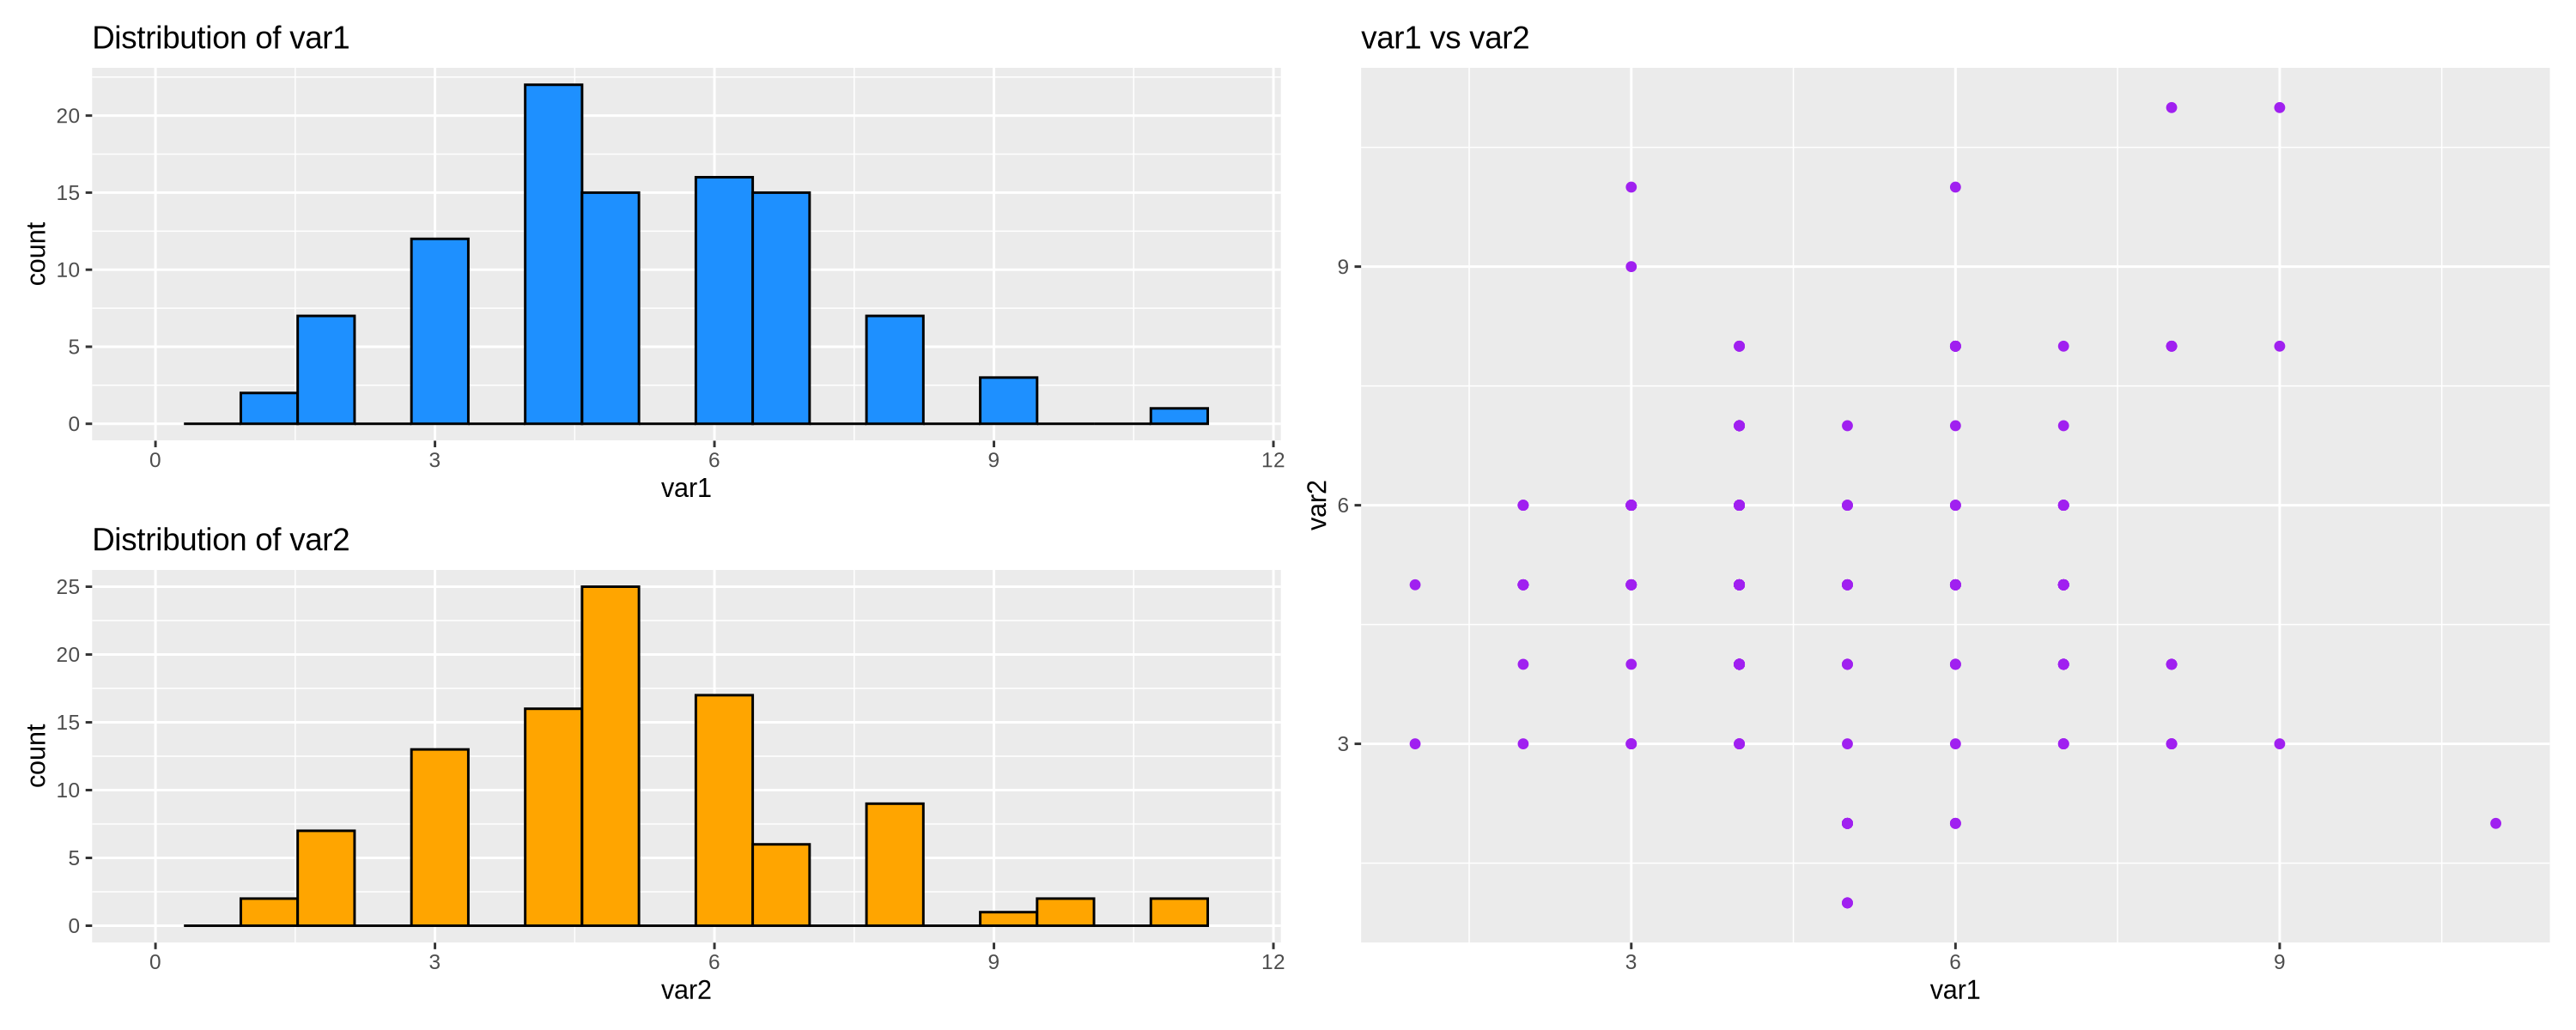

In [29]:
options(repr.plot.width = 15, repr.plot.height = 6, repr.plot.res = 200)

set.seed(1)

n_samples <- 100
var1 <- rpois(n_samples, 5)
var2 <- rpois(n_samples, 5)

length(var1)
summary(var1)
length(var2)
summary(var2)

df <- data.frame(var1, var2)

# Create histograms for var1 and var2 with the same x-axis limits
x_limits <- range(c(var1, var2))
extension_fraction <- 0.05
new_max <- x_limits[2] + (x_limits[2] - x_limits[1]) * extension_fraction
x_limits <- c(-0.1, new_max)

hist_var1 <- ggplot(df, aes(x = var1)) +
    geom_histogram(bins = 20, fill = "dodgerblue", color = "black") +
    xlim(x_limits) +
    ggtitle("Distribution of var1")

hist_var2 <- ggplot(df, aes(x = var2)) +
    geom_histogram(bins = 20, fill = "orange", color = "black") +
    xlim(x_limits) +
    ggtitle("Distribution of var2")

# Create a scatterplot of var1 vs var2
scatter_plot <- ggplot(df, aes(x = var1, y = var2)) +
    geom_point(color = "purple") +
    ggtitle("var1 vs var2")

# Combine the plots into two columns
(hist_var1 / hist_var2) | scatter_plot +
    plot_layout(axis_titles = "collect")


In [30]:
# By hand

X <- mean(var1)
Y <- mean(var2)
head(X - var1)
head(Y - var2)

"-----Covariance------"
sum((X - var1) * (Y - var2)) / (n_samples - 1) # note the "- 1"


[1]  1.1  1.1  0.1 -2.9  2.1 -2.9

[1] -0.89  1.11  1.11 -5.89 -0.89  2.11

[1] "-----Covariance------"

[1] 0.2515152

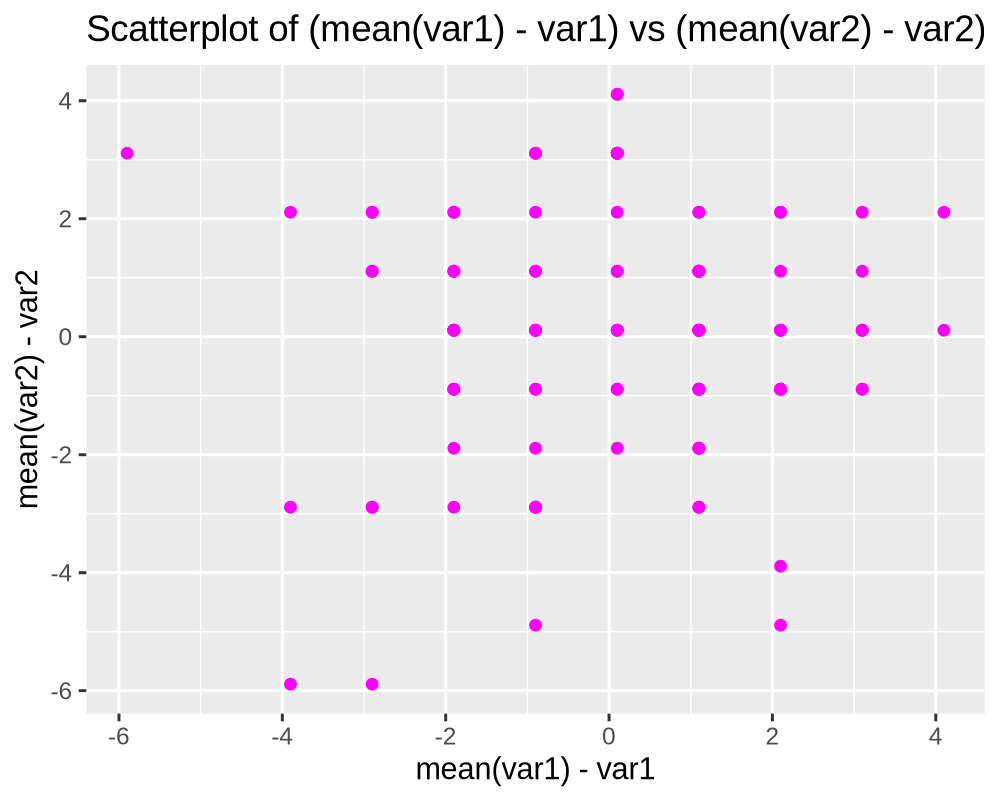

In [31]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 200)

# Create a data frame for the differences
df_diff <- data.frame(diff_var1 = X - var1, diff_var2 = Y - var2)

scatter_diff_plot <- ggplot(df_diff, aes(x = diff_var1, y = diff_var2)) +
    geom_point(color = "magenta") +
    ggtitle("Scatterplot of (mean(var1) - var1) vs (mean(var2) - var2)") +
    xlab("mean(var1) - var1") +
    ylab("mean(var2) - var2")

scatter_diff_plot


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


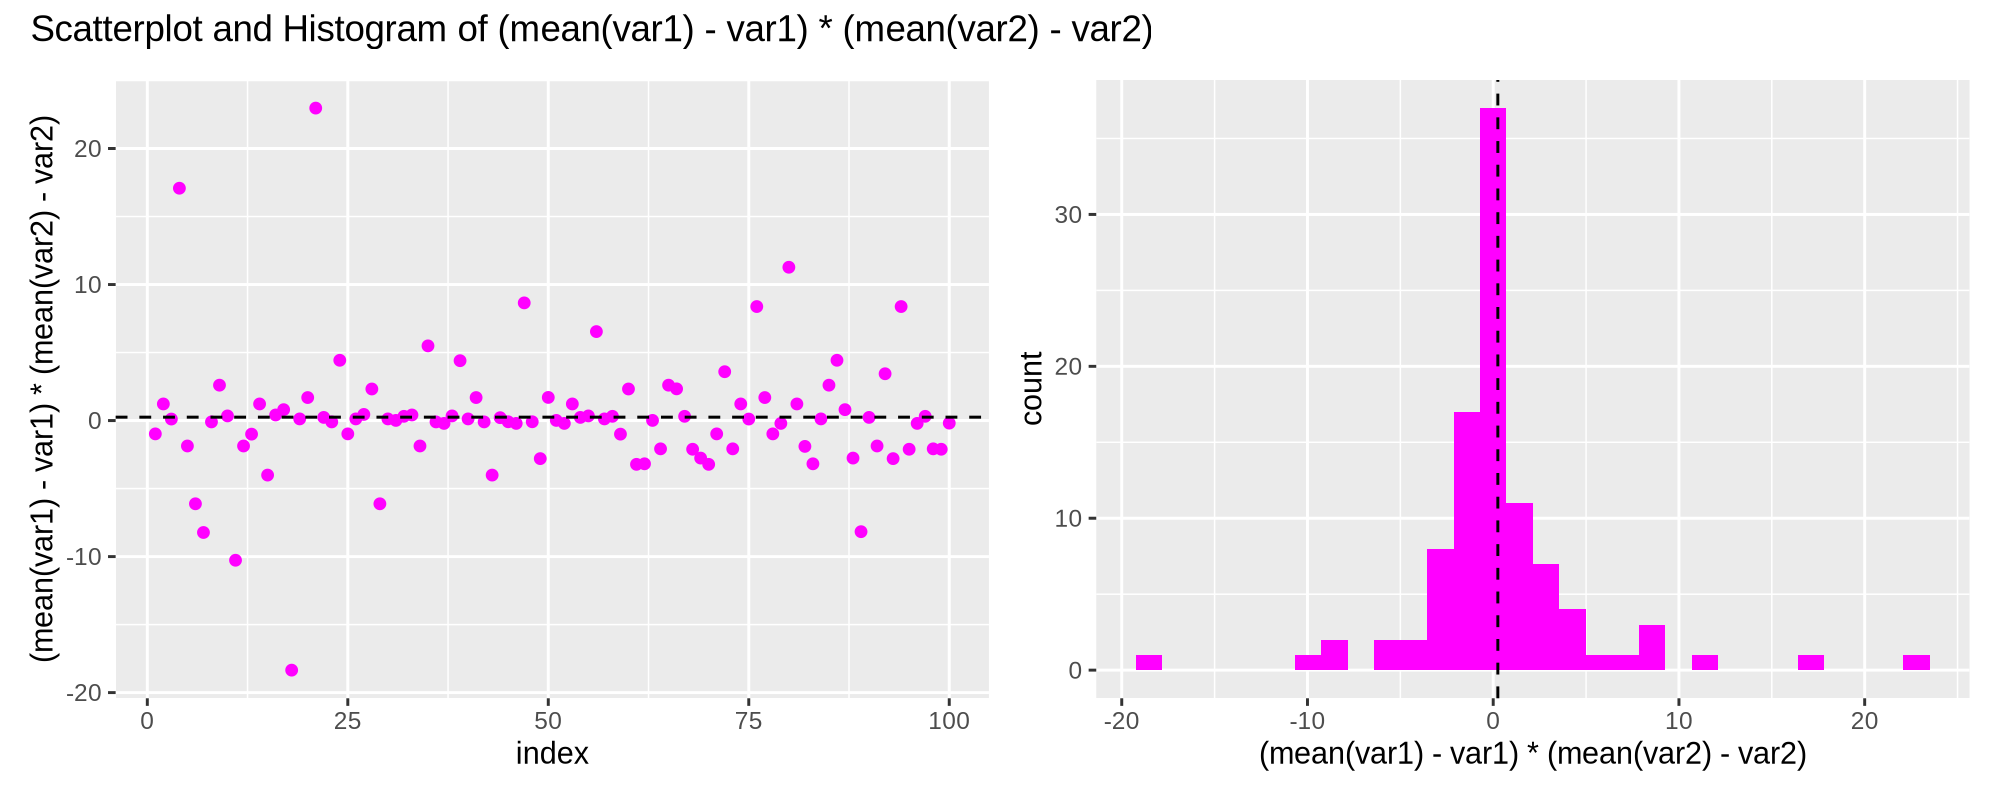

In [32]:
options(repr.plot.width = 10, repr.plot.height = 4, repr.plot.res = 200)

# Create a data frame for the differences
df_diff <- data.frame(covariance = (X - var1) * (Y - var2), x = 1:n_samples)
# Calculate the mean of the (almost) covariance
mean_covariance <- mean(df_diff$covariance)

scatter_plot <- ggplot(df_diff, aes(x = x, y = covariance)) +
    geom_point(color = "magenta") +
    geom_hline(yintercept = mean_covariance, color = "black", linetype = "dashed") +
    xlab("index") +
    ylab("(mean(var1) - var1) * (mean(var2) - var2)")
hist_plot <- ggplot(df_diff, aes(x = covariance)) +
    geom_histogram(fill = "magenta") +
    geom_vline(xintercept = mean_covariance, color = "black", linetype = "dashed") +
    xlab("(mean(var1) - var1) * (mean(var2) - var2)")

scatter_plot + hist_plot +
    plot_annotation(title = "Scatterplot and Histogram of (mean(var1) - var1) * (mean(var2) - var2)")


## Variance


### Correlated variables


[1] 100

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    1.0     4.0     5.0     5.1     7.0    11.0 

[1] 100

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 -4.383   5.782   9.758  10.112  14.296  29.328 

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


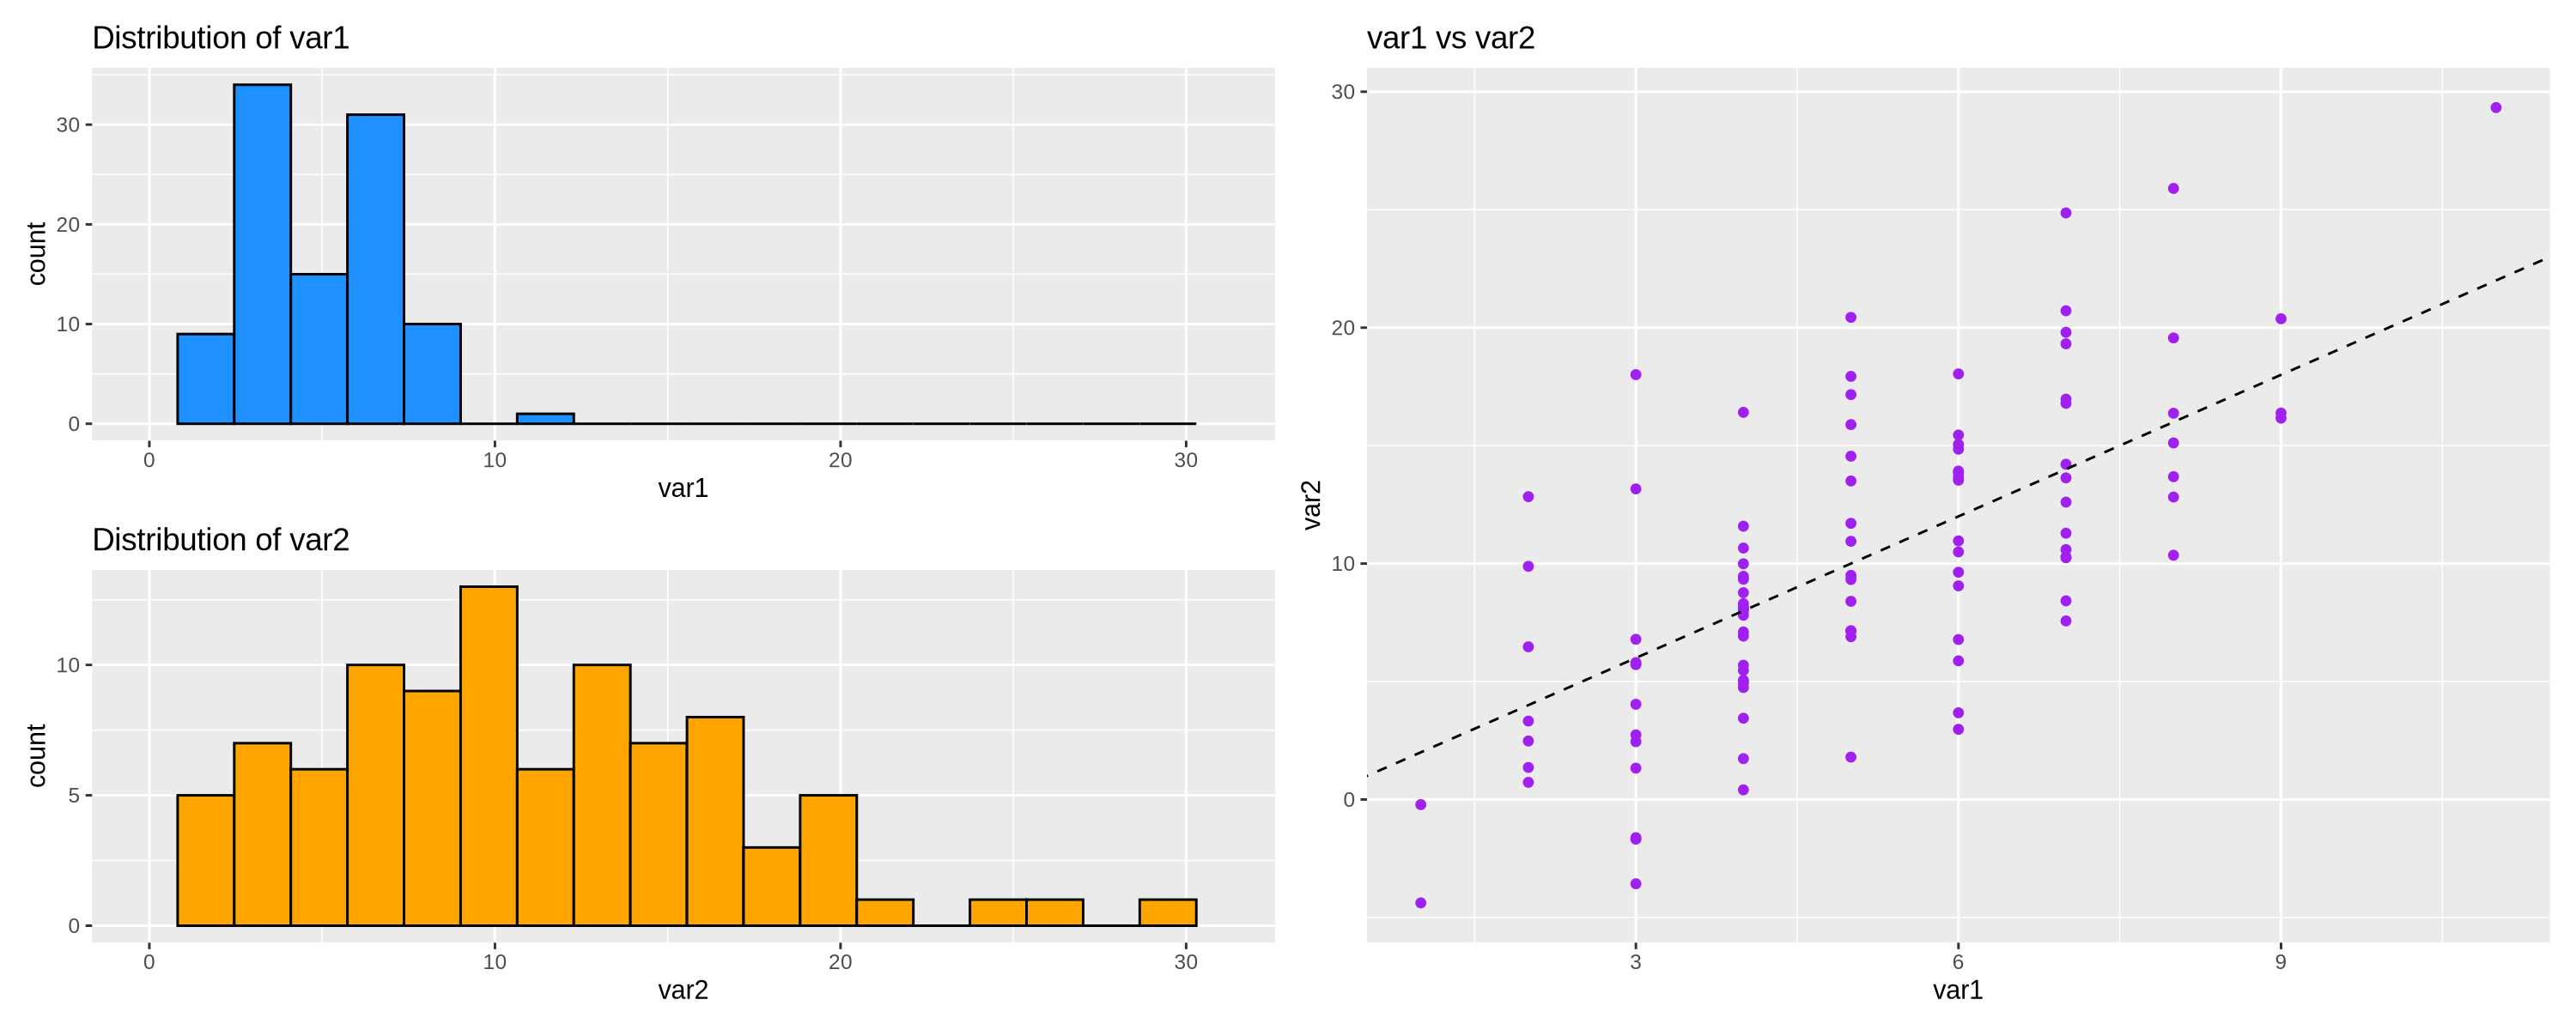

In [33]:
options(repr.plot.width = 15, repr.plot.height = 6, repr.plot.res = 200)

set.seed(1)

n_samples <- 100
var1 <- rpois(n_samples, 5)
var2 <- (var1 * 2) + rnorm(n_samples, 0, 5)

length(var1)
summary(var1)
length(var2)
summary(var2)

df <- data.frame(var1, var2)

# Create histograms for var1 and var2 with the same x-axis limits
x_limits <- range(c(var1, var2))
extension_fraction <- 0.05
new_max <- x_limits[2] + (x_limits[2] - x_limits[1]) * extension_fraction
x_limits <- c(-0.1, new_max)

hist_var1 <- ggplot(df, aes(x = var1)) +
    geom_histogram(bins = 20, fill = "dodgerblue", color = "black") +
    xlim(x_limits) +
    ggtitle("Distribution of var1")

hist_var2 <- ggplot(df, aes(x = var2)) +
    geom_histogram(bins = 20, fill = "orange", color = "black") +
    xlim(x_limits) +
    ggtitle("Distribution of var2")

# Create a scatterplot of var1 vs var2
scatter_plot <- ggplot(df, aes(x = var1, y = var2)) +
    geom_point(color = "purple") +
    geom_abline(slope = 2, intercept = 0, color = "black", linetype = "dashed") +
    ggtitle("var1 vs var2")

# Combine the plots into two columns
(hist_var1 / hist_var2) | scatter_plot +
    plot_layout(axis_titles = "collect")


In [34]:
print("var1")
paste("Built-in:", var(var1))
paste("By hand:", sum((mean(var1) - var1) * (mean(var1) - var1)) / (n_samples - 1))

print("var2")
paste("Built-in:", var(var2))
paste("By hand:", sum((mean(var2) - var2) * (mean(var2) - var2)) / (n_samples - 1))

X <- mean(var1)
Y <- mean(var2)


[1] "var1"


[1] "Built-in: 3.90909090909091"

[1] "By hand: 3.90909090909091"

[1] "var2"


[1] "Built-in: 41.974860767602"

[1] "By hand: 41.974860767602"

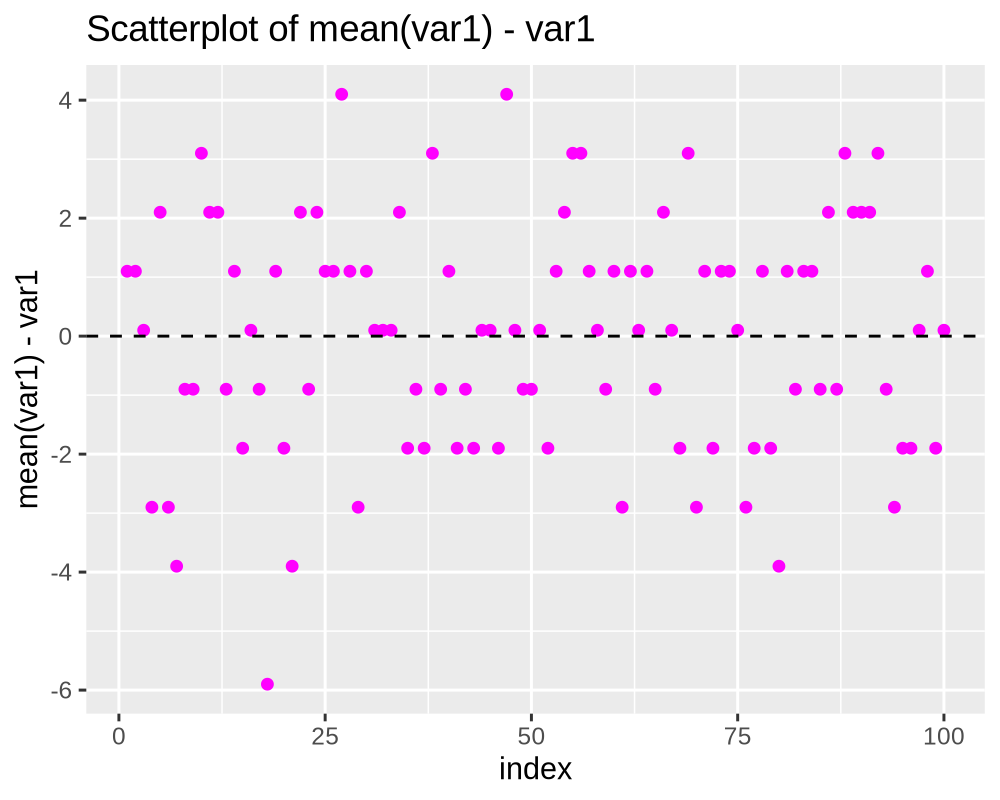

In [35]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 200)

# Create a data frame for the differences
df_diff <- data.frame(diff_var1 = X - var1, x = 1:n_samples)
mean_diff_var1 <- mean(df_diff$diff_var1)

# Create the scatterplot
scatter_diff_plot <- ggplot(df_diff, aes(x = x, y = diff_var1)) +
    geom_point(color = "magenta") +
    geom_hline(yintercept = mean_diff_var1, color = "black", linetype = "dashed") +
    ggtitle("Scatterplot of mean(var1) - var1") +
    xlab("index") +
    ylab("mean(var1) - var1")

scatter_diff_plot


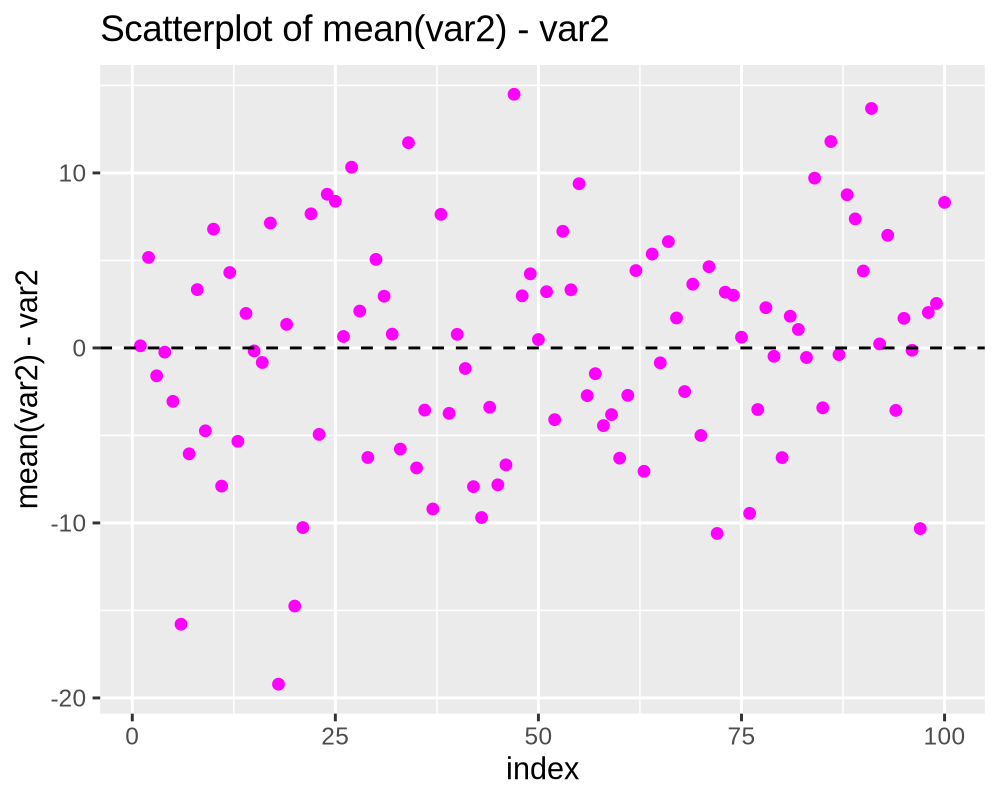

In [36]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 200)

# Create a data frame for the differences
df_diff <- data.frame(diff_var2 = Y - var2, x = 1:n_samples)
mean_diff_var2 <- mean(df_diff$diff_var2)

# Create the scatterplot
scatter_diff_plot <- ggplot(df_diff, aes(x = x, y = diff_var2)) +
    geom_point(color = "magenta") +
    geom_hline(yintercept = mean_diff_var2, color = "black", linetype = "dashed") +
    ggtitle("Scatterplot of mean(var2) - var2") +
    xlab("index") +
    ylab("mean(var2) - var2")

scatter_diff_plot


- A larger variance for var2 shows in a larger difference of each value to the mean of var2 when compared to var1


### Uncorrelated variables


[1] 1000

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   3.000   5.000   5.027   6.000  15.000 

[1] 1000

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   3.000   5.000   4.922   6.000  13.000 

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


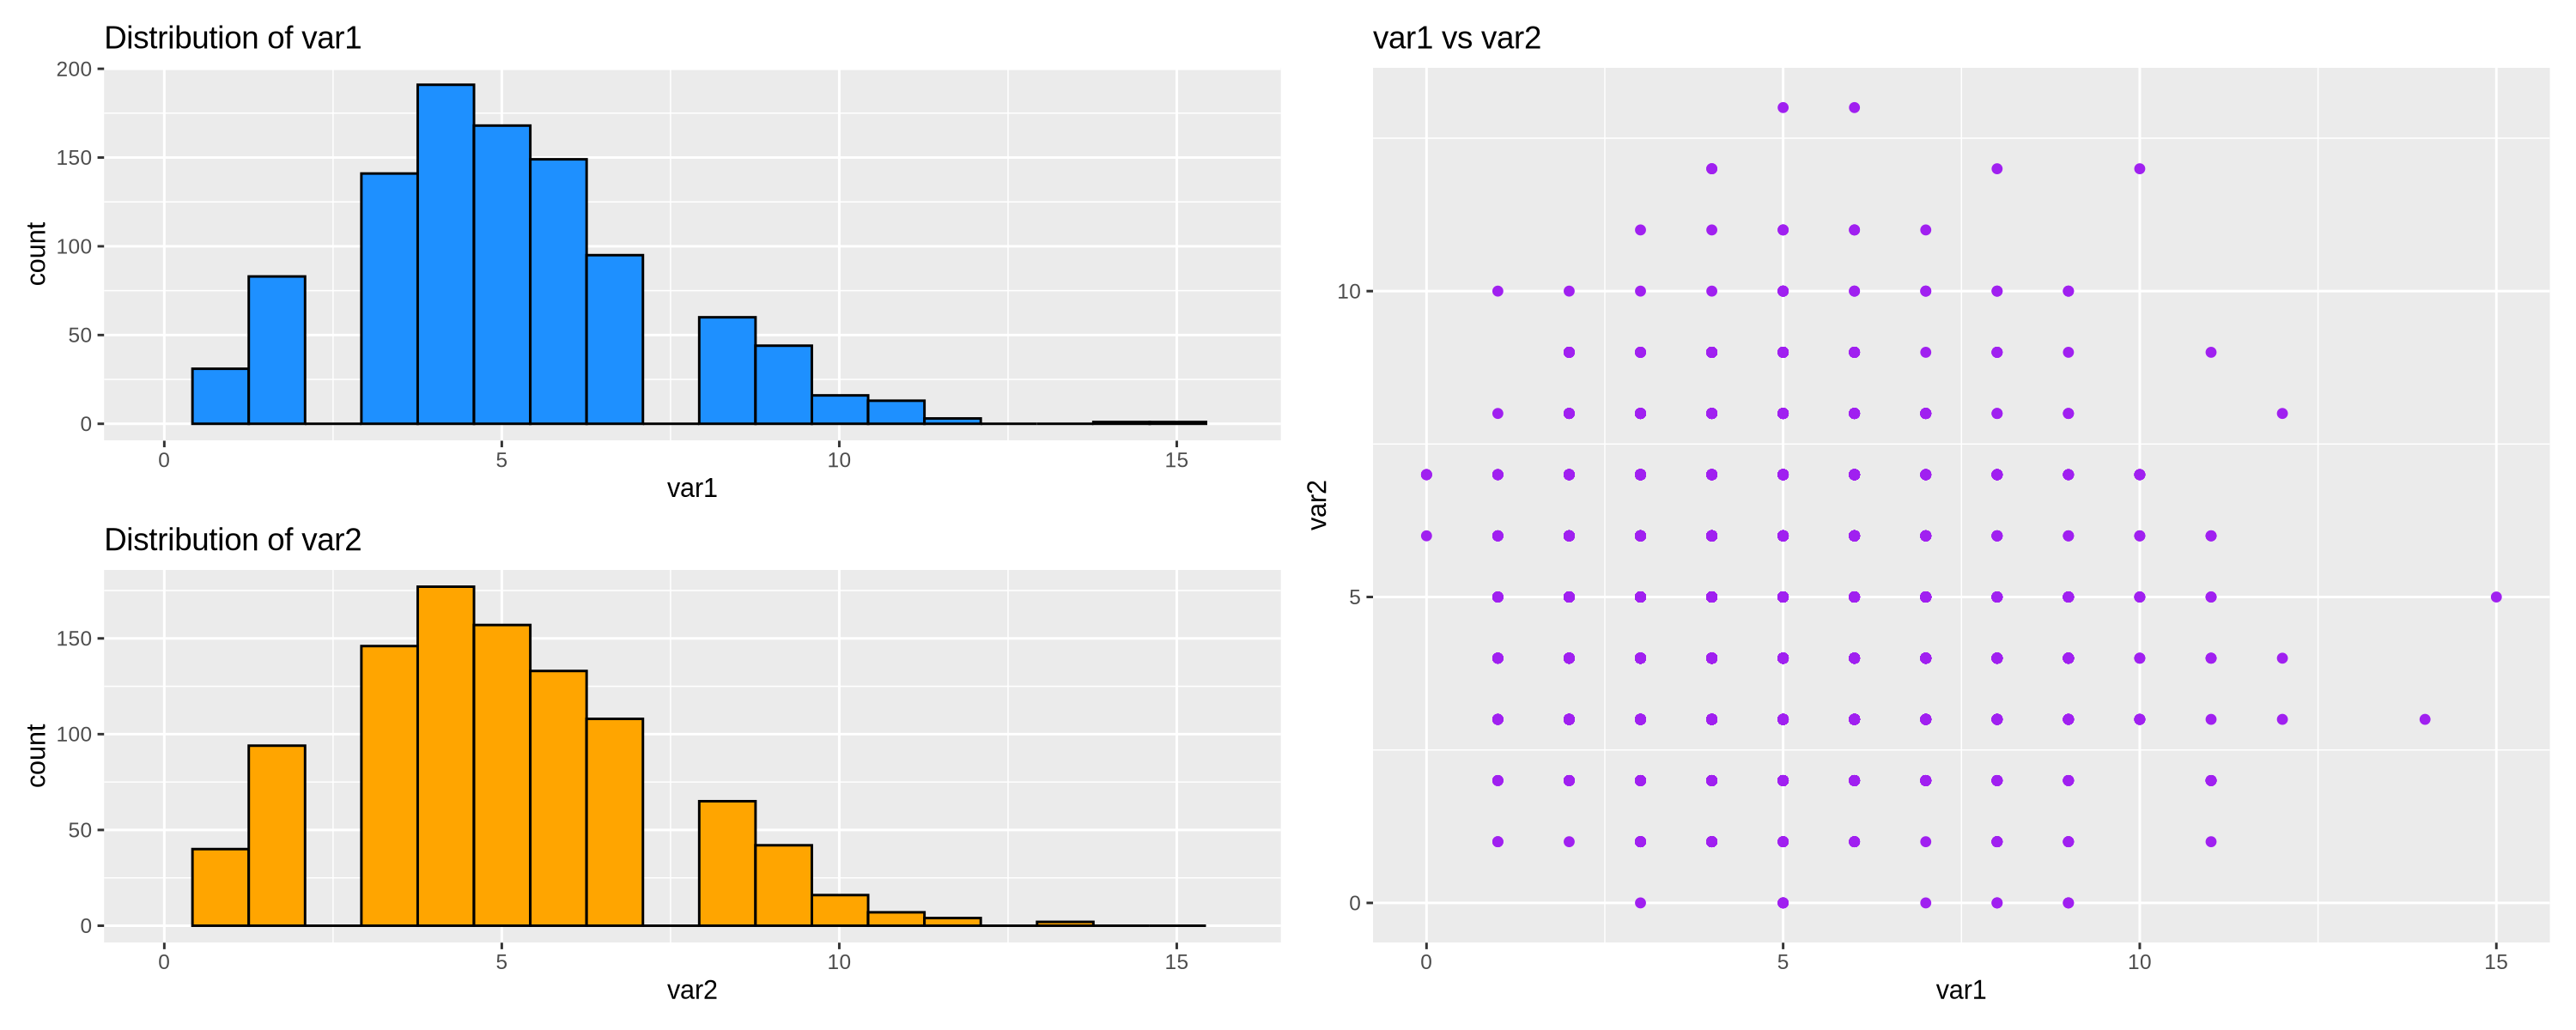

In [51]:
options(repr.plot.width = 15, repr.plot.height = 6, repr.plot.res = 200)

set.seed(1)

n_samples <- 1000
var1 <- rpois(n_samples, 5)
var2 <- rpois(n_samples, 5)

length(var1)
summary(var1)
length(var2)
summary(var2)

df <- data.frame(var1, var2)

# Create histograms for var1 and var2 with the same x-axis limits
x_limits <- range(c(var1, var2))
extension_fraction <- 0.05
new_max <- x_limits[2] + (x_limits[2] - x_limits[1]) * extension_fraction
x_limits <- c(-0.1, new_max)

hist_var1 <- ggplot(df, aes(x = var1)) +
    geom_histogram(bins = 20, fill = "dodgerblue", color = "black") +
    xlim(x_limits) +
    ggtitle("Distribution of var1")

hist_var2 <- ggplot(df, aes(x = var2)) +
    geom_histogram(bins = 20, fill = "orange", color = "black") +
    xlim(x_limits) +
    ggtitle("Distribution of var2")

# Create a scatterplot of var1 vs var2
scatter_plot <- ggplot(df, aes(x = var1, y = var2)) +
    geom_point(color = "purple") +
    ggtitle("var1 vs var2")

# Combine the plots into two columns
(hist_var1 / hist_var2) | scatter_plot +
    plot_layout(axis_titles = "collect")


In [55]:
print("var1")
paste("Built-in:", var(var1))
paste("By hand:", sum((mean(var1) - var1) * (mean(var1) - var1)) / (n_samples - 1))

print("var2")
paste("Built-in:", var(var2))
paste("By hand:", sum((mean(var2) - var2) * (mean(var2) - var2)) / (n_samples - 1))

X <- mean(var1)
Y <- mean(var2)

X
Y


[1] "var1"


[1] "Built-in: 5.07134234234234"

[1] "By hand: 5.07134234234234"

[1] "var2"


[1] "Built-in: 5.26918518518518"

[1] "By hand: 5.26918518518519"

[1] 5.027

[1] 4.922

- Note that since they are poisson-distributed variables, var(x) = E(X)


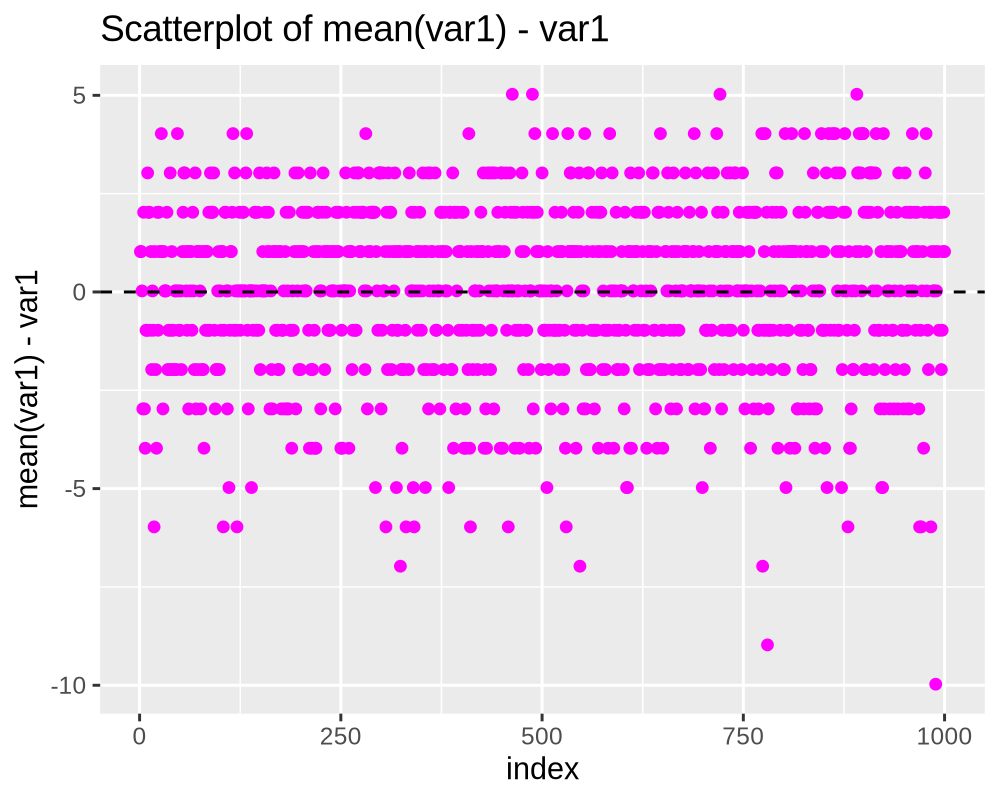

In [53]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 200)

# Create a data frame for the differences
df_diff <- data.frame(diff_var1 = X - var1, x = 1:n_samples)
mean_diff_var1 <- mean(df_diff$diff_var1)

# Create the scatterplot
scatter_diff_plot <- ggplot(df_diff, aes(x = x, y = diff_var1)) +
    geom_point(color = "magenta") +
    geom_hline(yintercept = mean_diff_var1, color = "black", linetype = "dashed") +
    ggtitle("Scatterplot of mean(var1) - var1") +
    xlab("index") +
    ylab("mean(var1) - var1")

scatter_diff_plot


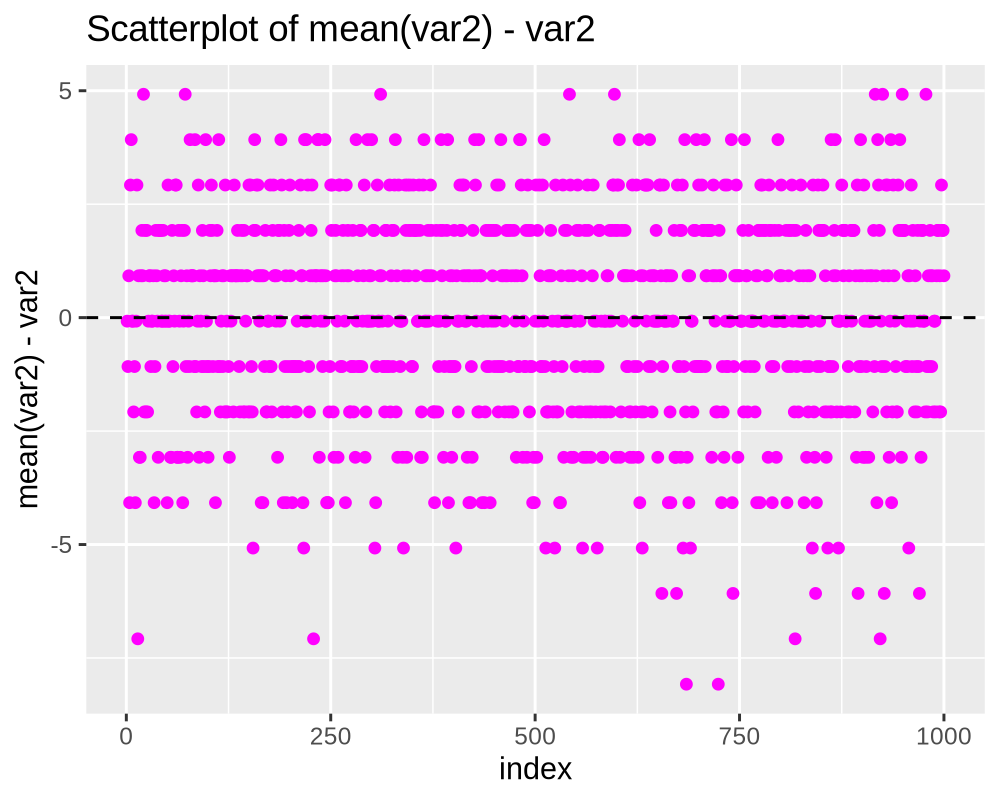

In [54]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 200)

# Create a data frame for the differences
df_diff <- data.frame(diff_var2 = Y - var2, x = 1:n_samples)
mean_diff_var2 <- mean(df_diff$diff_var2)

# Create the scatterplot
scatter_diff_plot <- ggplot(df_diff, aes(x = x, y = diff_var2)) +
    geom_point(color = "magenta") +
    geom_hline(yintercept = mean_diff_var2, color = "black", linetype = "dashed") +
    ggtitle("Scatterplot of mean(var2) - var2") +
    xlab("index") +
    ylab("mean(var2) - var2")

scatter_diff_plot


### Variance of sums


[1] 1000

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   3.000   5.000   5.027   6.000  15.000 

[1] 1000

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-12.572   4.984  10.060   9.932  14.008  32.029 

[1] 1000

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   4.000   6.000   5.996   8.000  15.000 

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 73 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


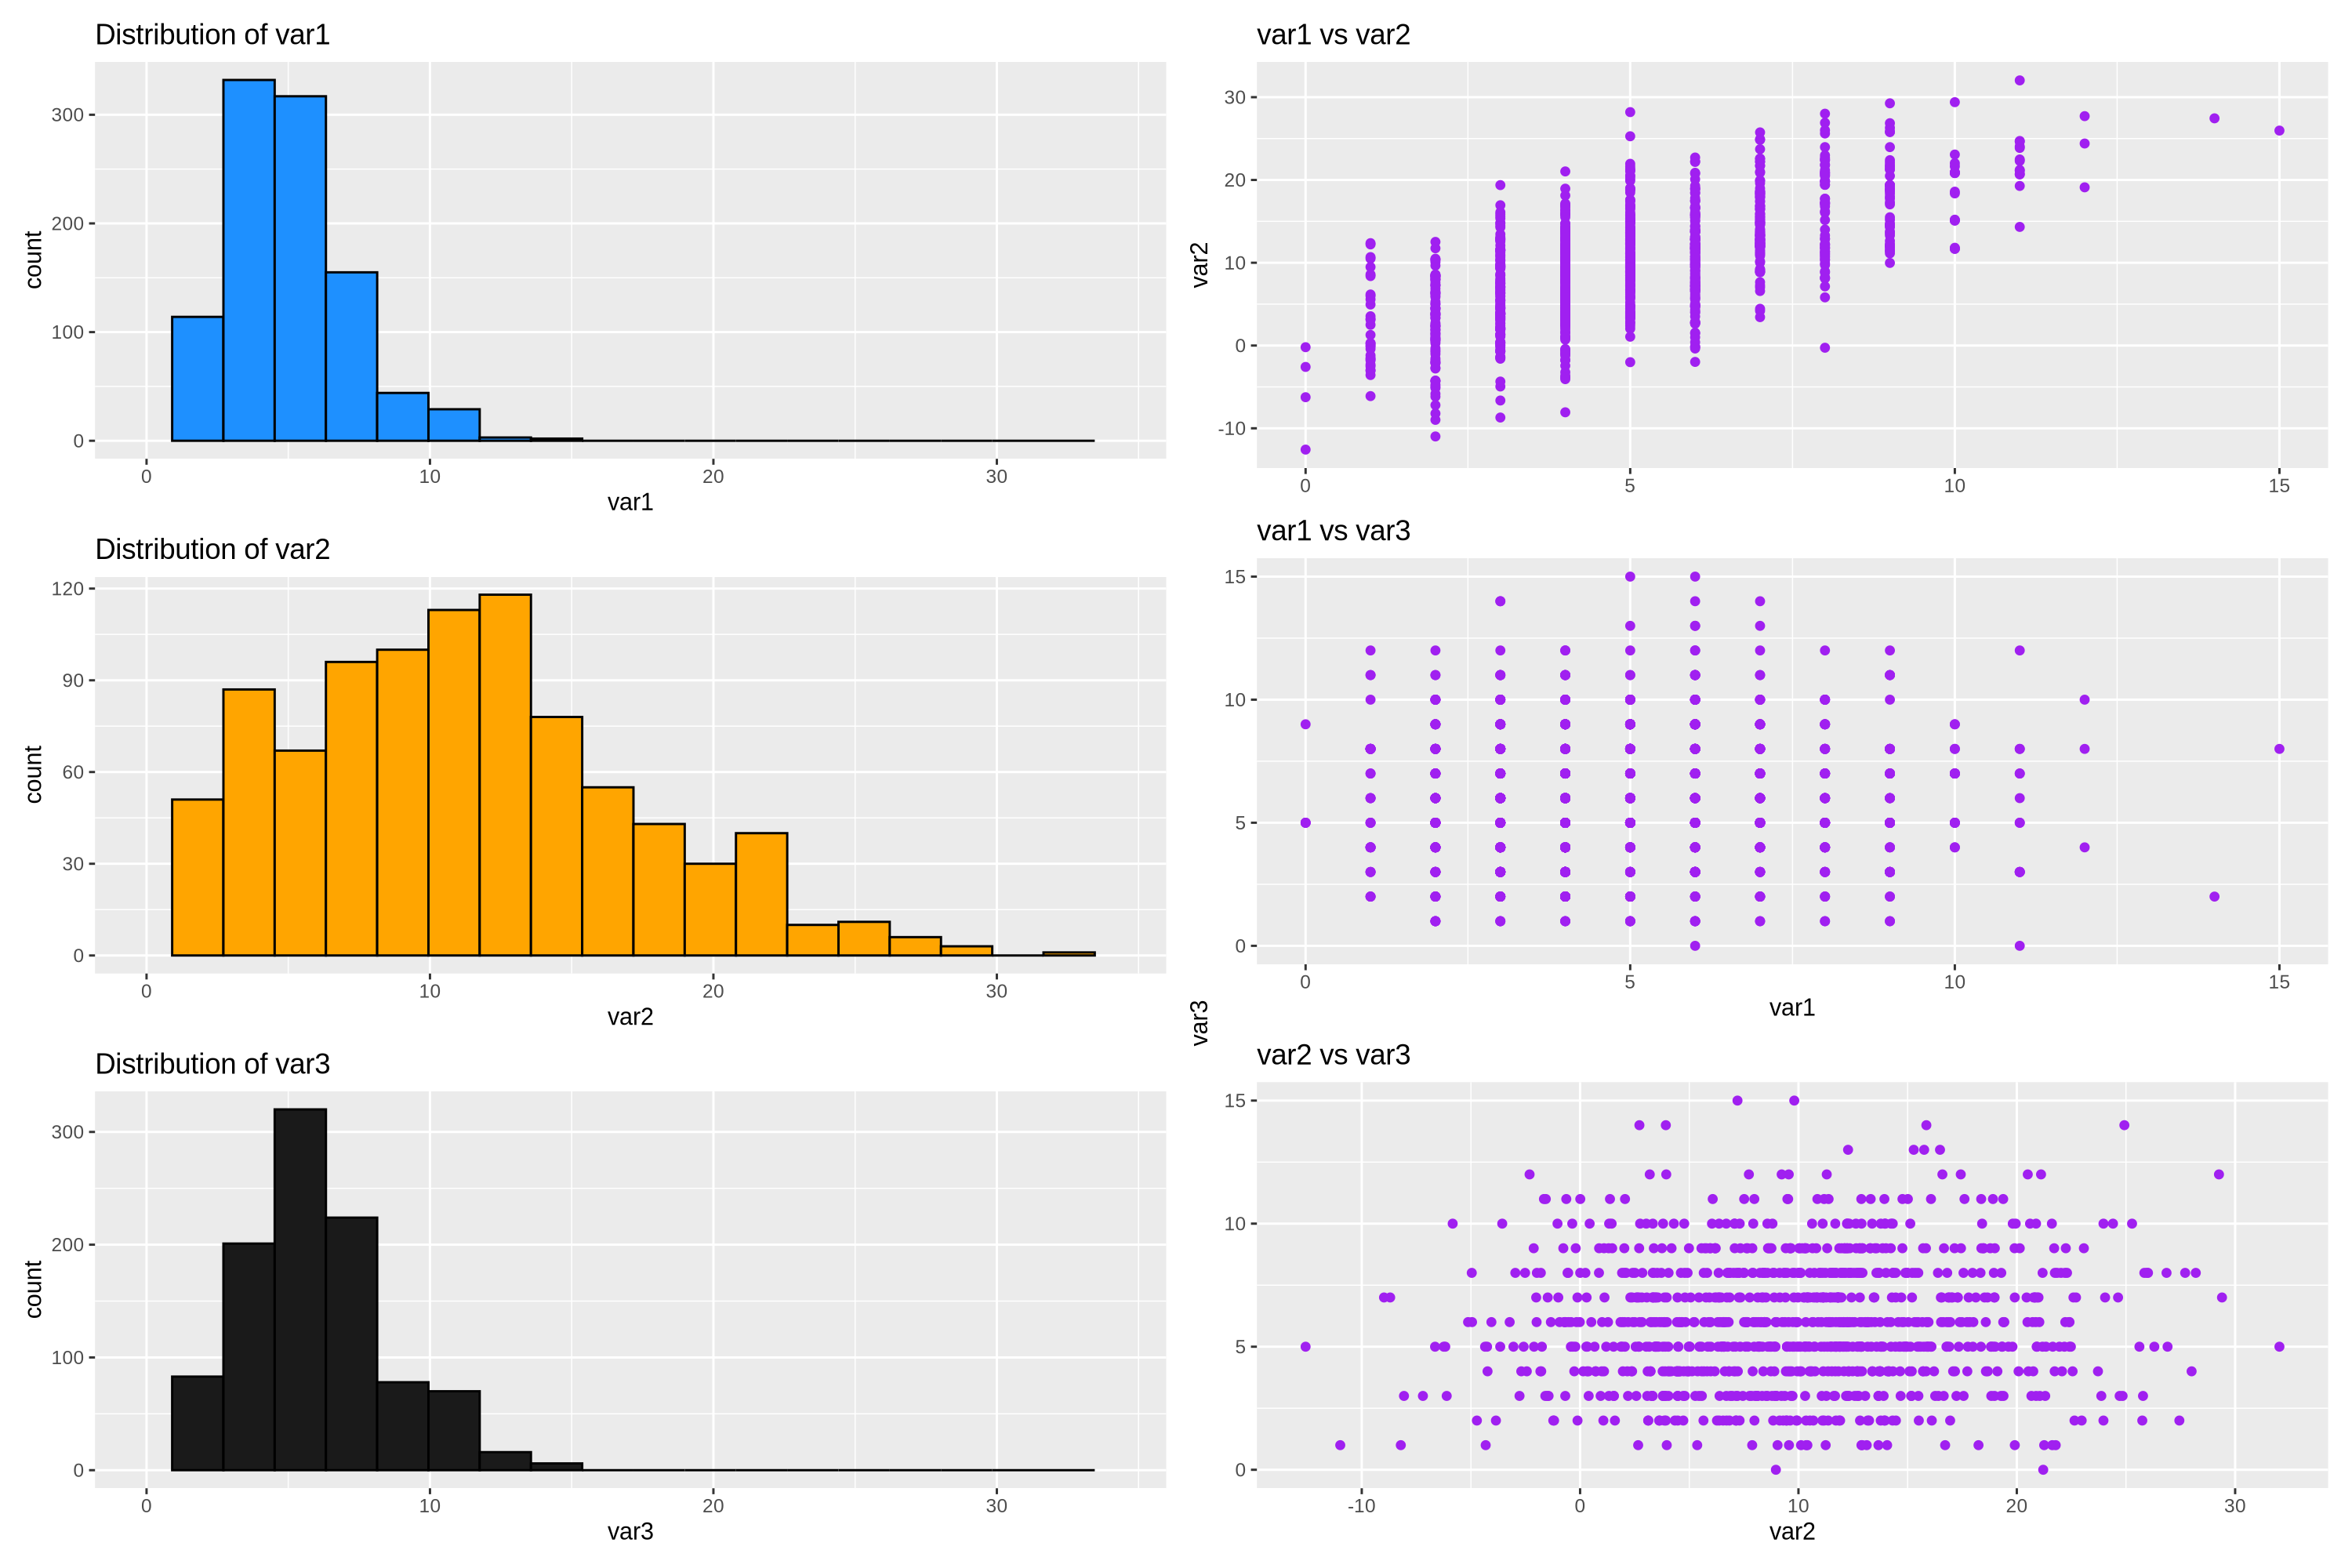

In [42]:
options(repr.plot.width = 15, repr.plot.height = 10, repr.plot.res = 200)

set.seed(1)

n_samples <- 1000
var1 <- rpois(n_samples, 5)
var2 <- (var1 * 2) + rnorm(n_samples, 0, 5)
var3 <- rpois(n_samples, 6)

length(var1)
summary(var1)
length(var2)
summary(var2)
length(var3)
summary(var3)

df <- data.frame(var1, var2)

# Create histograms for var1 and var2 with the same x-axis limits
x_limits <- range(c(var1, var2))
extension_fraction <- 0.05
new_max <- x_limits[2] + (x_limits[2] - x_limits[1]) * extension_fraction
x_limits <- c(-0.1, new_max)

hist_var1 <- ggplot(df, aes(x = var1)) +
    geom_histogram(bins = 20, fill = "dodgerblue", color = "black") +
    xlim(x_limits) +
    ggtitle("Distribution of var1")

hist_var2 <- ggplot(df, aes(x = var2)) +
    geom_histogram(bins = 20, fill = "orange", color = "black") +
    xlim(x_limits) +
    ggtitle("Distribution of var2")

hist_var3 <- ggplot(df, aes(x = var3)) +
    geom_histogram(bins = 20, fill = "grey10", color = "black") +
    xlim(x_limits) +
    ggtitle("Distribution of var3")

scatter_plot <- ggplot(df, aes(x = var1, y = var2)) +
    geom_point(color = "purple") +
    ggtitle("var1 vs var2") +
    xlab("var1") +
    ylab("var2")

scatter_plot_var1_var3 <- ggplot(df, aes(x = var1, y = var3)) +
    geom_point(color = "purple") +
    ggtitle("var1 vs var3") +
    xlab("var1") +
    ylab("var3")

scatter_plot_var2_var3 <- ggplot(df, aes(x = var2, y = var3)) +
    geom_point(color = "purple") +
    ggtitle("var2 vs var3") +
    xlab("var2") +
    ylab("var3")

# Combine the plots into two columns
(hist_var1 / hist_var2 / hist_var3) | (scatter_plot / scatter_plot_var1_var3 / scatter_plot_var2_var3) +
    plot_layout(axis_titles = "collect")


In [43]:
var12 <- var1 + var2
cat("Variance from sum((E(X) - X)²)/n-1: ", var(var12), sep = "\n")
cat("Variance from covariance: ", var(var1) + var(var2) + (2 * cov(var1, var2)), sep = "\n")

var13 <- var1 + var3
cat("Variance from sum((E(X) - X)²)/n-1: ", var(var13), sep = "\n")
cat("Variance from covariance: ", var(var1) + var(var3) + (2 * cov(var1, var3)), sep = "\n")

var123 <- var1 + var2 + var3
cat("Variance from sum((E(X) - X)²)/n-1: ", var(var123), sep = "\n")
cat("Variance from covariance: ", var(var1) + var(var2) + var(var3) +
    (2 * cov(var1, var2)) + (2 * cov(var1, var3)) + (2 * cov(var2, var3)), sep = "\n")


Variance from sum((E(X) - X)²)/n-1: 
72.75838
Variance from covariance: 
72.75838
Variance from sum((E(X) - X)²)/n-1: 
12.08856
Variance from covariance: 
12.08856
Variance from sum((E(X) - X)²)/n-1: 
81.94044
Variance from covariance: 
81.94044


- The variance of a sum of variables is the sum of the pairwise covariances


In [ ]:
var(var13)
var(var1) + var(var3)

cov(var1, var3)


[1] 12.08856

[1] 11.78804

[1] 0.1502583

- Variance of the sum of variables should be equal to the sum of the individual variances
- In this case it seems that the variables are slightly correlated (by chance, bigger n would solve this issue)


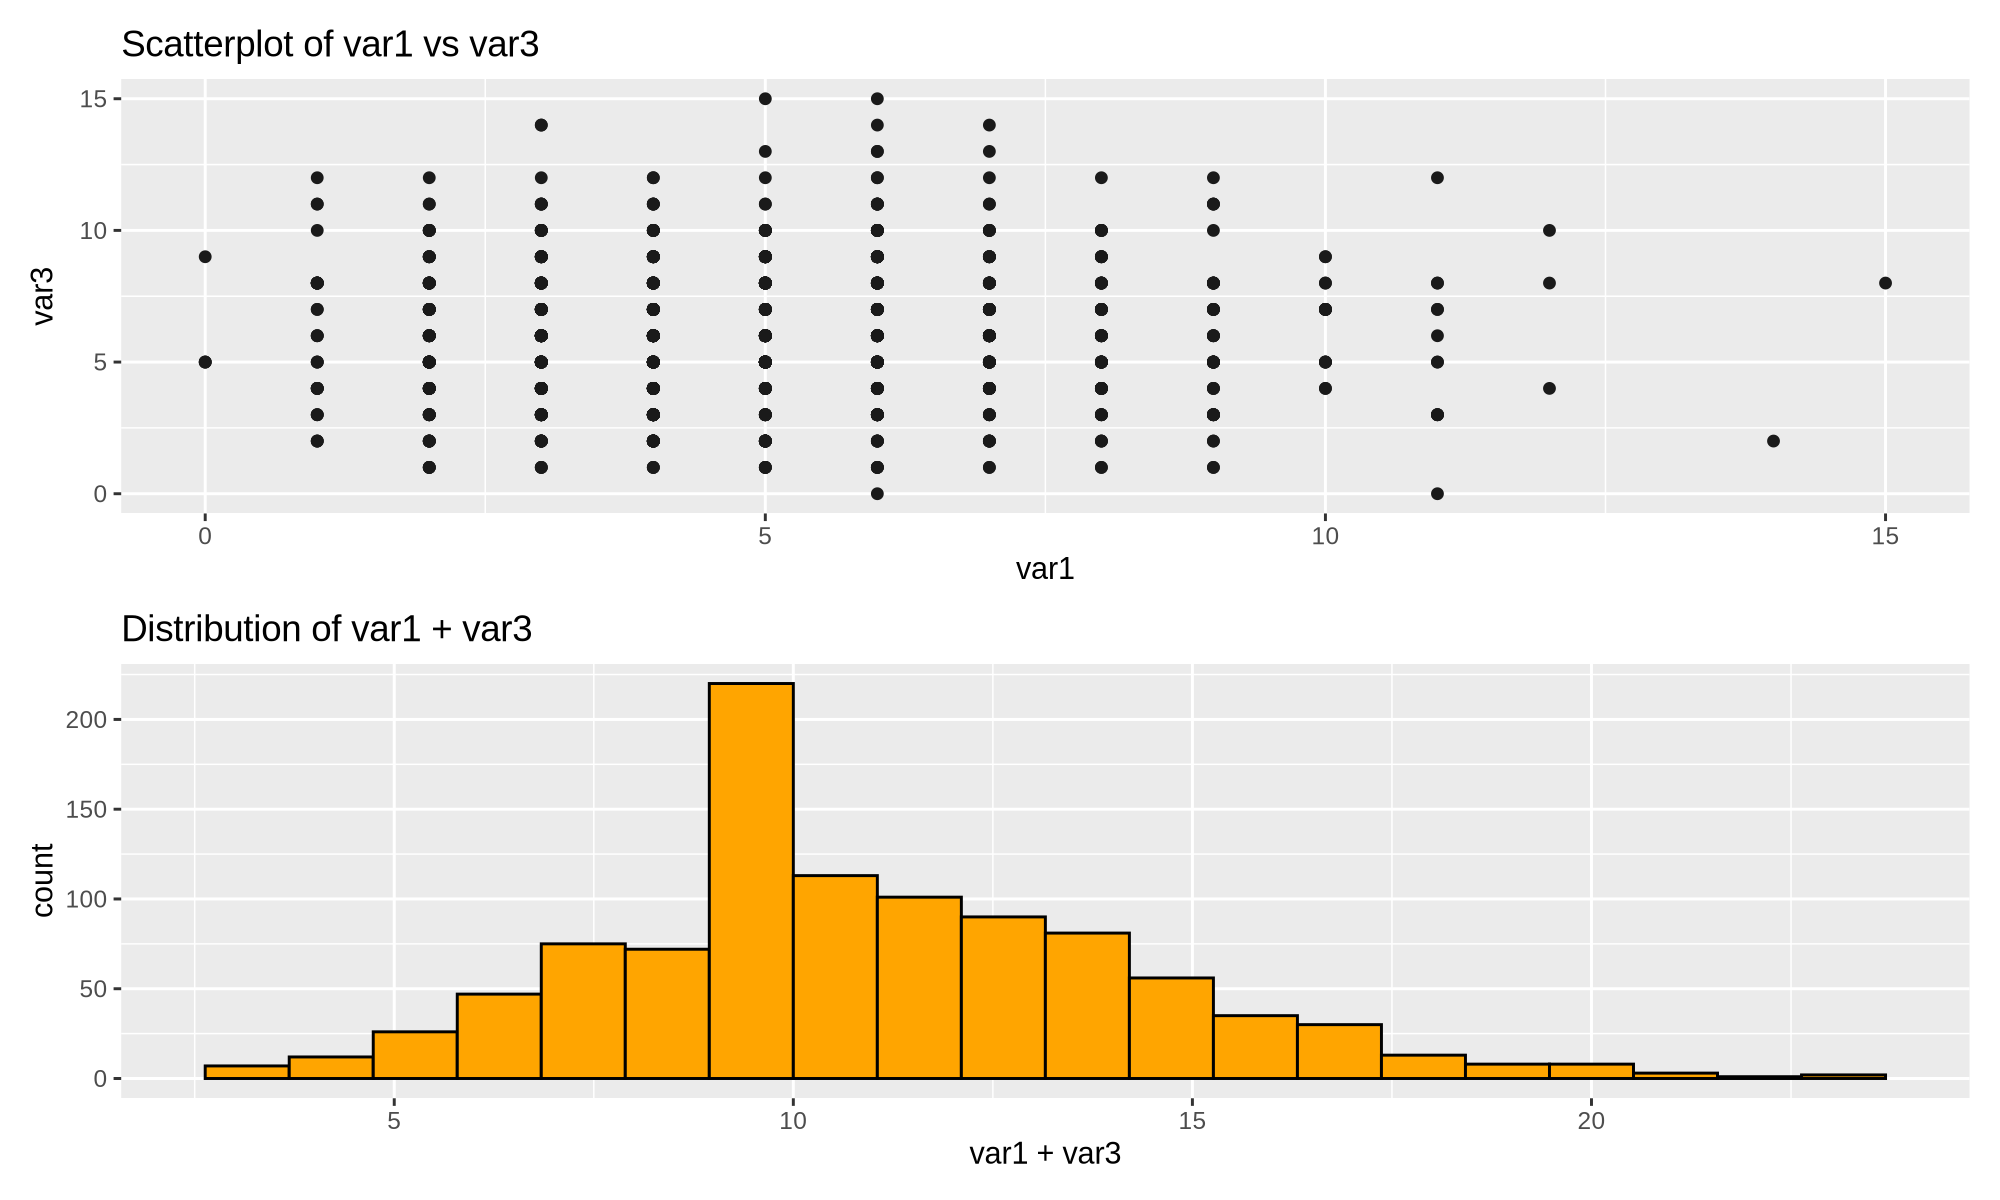

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 6, repr.plot.res = 200)

# Create a data frame for visualization
df_vis <- data.frame(var1 = var1, var3 = var3, sum_var13 = var13)

# Scatterplot of var1 vs var3
scatter_var1_var3 <- ggplot(df_vis, aes(x = var1, y = var3)) +
    geom_point(color = "grey10") +
    ggtitle("Scatterplot of var1 vs var3") +
    xlab("var1") +
    ylab("var3")

# Histogram of the sum of var1 and var3
hist_sum_var13 <- ggplot(df_vis, aes(x = sum_var13)) +
    geom_histogram(bins = 20, fill = "orange", color = "black") +
    ggtitle("Distribution of var1 + var3") +
    xlab("var1 + var3")

# Combine the plots
scatter_var1_var3 / hist_sum_var13


## Correlation


[1] 100

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    1.0     4.0     5.0     5.1     7.0    11.0 

[1] 100

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 -4.383   5.782   9.758  10.112  14.296  29.328 

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


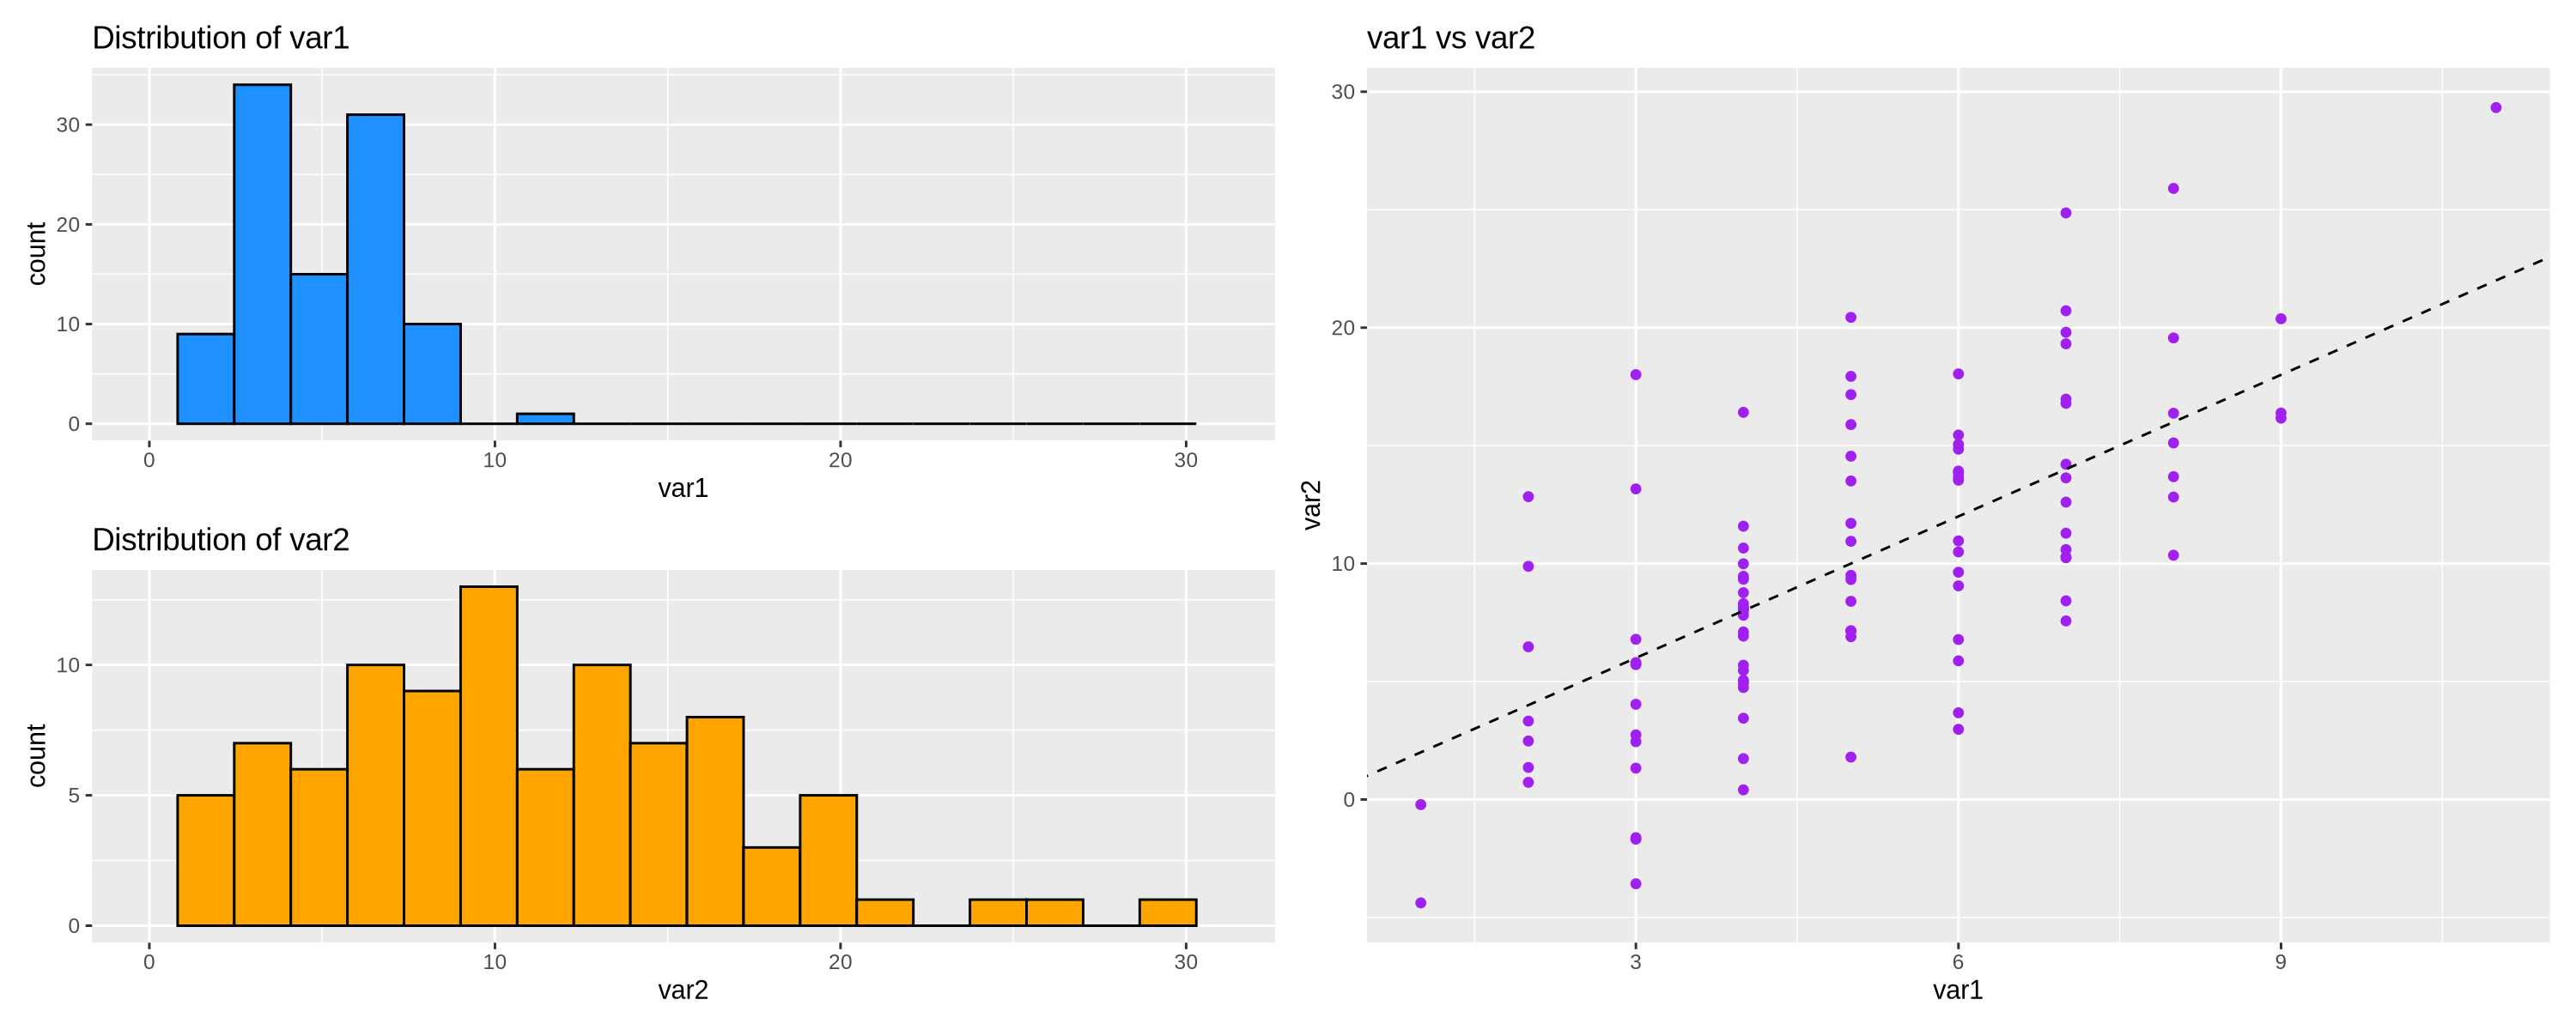

In [41]:
options(repr.plot.width = 15, repr.plot.height = 6, repr.plot.res = 200)

set.seed(1)

n_samples <- 100
var1 <- rpois(n_samples, 5)
var2 <- (var1 * 2) + rnorm(n_samples, 0, 5)

length(var1)
summary(var1)
length(var2)
summary(var2)

df <- data.frame(var1, var2)

# Create histograms for var1 and var2 with the same x-axis limits
x_limits <- range(c(var1, var2))
extension_fraction <- 0.05
new_max <- x_limits[2] + (x_limits[2] - x_limits[1]) * extension_fraction
x_limits <- c(-0.1, new_max)

hist_var1 <- ggplot(df, aes(x = var1)) +
    geom_histogram(bins = 20, fill = "dodgerblue", color = "black") +
    xlim(x_limits) +
    ggtitle("Distribution of var1")

hist_var2 <- ggplot(df, aes(x = var2)) +
    geom_histogram(bins = 20, fill = "orange", color = "black") +
    xlim(x_limits) +
    ggtitle("Distribution of var2")

# Create a scatterplot of var1 vs var2
scatter_plot <- ggplot(df, aes(x = var1, y = var2)) +
    geom_point(color = "purple") +
    geom_abline(slope = 2, intercept = 0, color = "black", linetype = "dashed") +
    ggtitle("var1 vs var2")

# Combine the plots into two columns
(hist_var1 / hist_var2) | scatter_plot +
    plot_layout(axis_titles = "collect")


In [53]:
mean_var1 <- mean(var1)
mean_var2 <- mean(var2)

covariance <- sum((mean_var1 - var1) * (mean_var2 - var2) / (n_samples - 1))

variance1 <- sum((mean_var1 - var1) * (mean_var1 - var1)) / (n_samples - 1)
variance2 <- sum((mean_var2 - var2) * (mean_var2 - var2)) / (n_samples - 1)

correlation <- covariance / sqrt(variance1 * variance2)
correlation

# Using the built-in cor() function to calculate correlation
correlation_builtin <- cor(var1, var2, method = "pearson")
correlation_builtin


[1] 0.6932424

[1] 0.6932424